PREPROCESSING DATA

In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

In [3]:
#LOAD DATA
df_train = pd.read_csv('data_training.csv')
df_test = pd.read_csv('data_testing.csv')

In [8]:
#EXPLORASI AWAL
print(df_train.info())
print(df_train.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB
None
       fixed acidity  volatile acidity  citric acid  residual sugar  \
co

In [10]:
#PENGECEKAN MISSING VALUE
print(df_train.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


karena tidak ada missing value jadi tidak memerlukan normalisasi atau skala ulang (feature scaling)

In [16]:
#MEMISAHKAN FITUR DAN TARGET PADA DATA TRAINING
X = df_train.drop(columns=['quality', 'Id'])
y = df_train['quality']

# Kolom 'Id' tidak berpengaruh pada kualitas, jadi kita hapus dari fitur
# Kolom 'quality' adalah target (y)


In [15]:
#MENYIAPKAN FITUR PADA DATA TESTING
test_ids = df_test['Id']
X_test_final = df_test.drop(columns=['Id'])

/tmp/ipykernel_934/2368382579.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.countplot(x=y, palette='viridis')


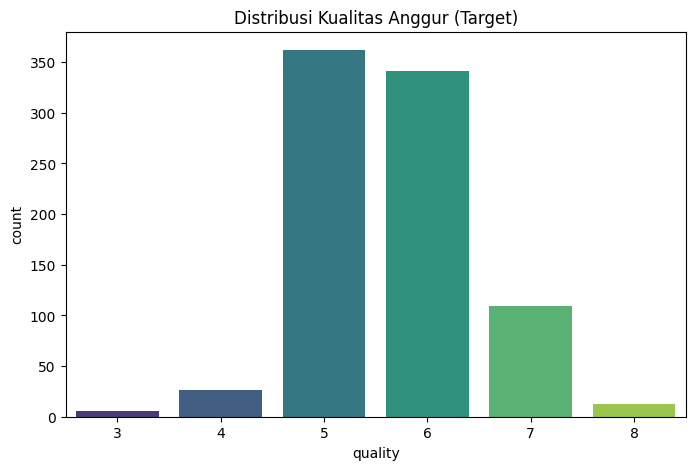

In [18]:
#VISUALISASI DISTRIBUSI TARGET (KUALITAS ANGGUR)
plt.figure(figsize=(8, 5))
sb.countplot(x=y, palette='viridis')
plt.title("Distribusi Kualitas Anggur (Target)")
plt.show()

PEMBUATAN MODEL

In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sb
import matplotlib.pyplot as plt

In [38]:
# Menentukann model: Saya mengunakan RandomForest dengan 100 pohon keputusan
model_wine = RandomForestClassifier(n_estimators=100, random_state=42)

In [39]:
model_wine.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [40]:
y_pred = model_wine.predict(X_val)

In [41]:
accuracy = accuracy_score(y_val, y_pred)
print(f"Akurasi Model: {accuracy * 100:.2f}%")

Akurasi Model: 58.72%


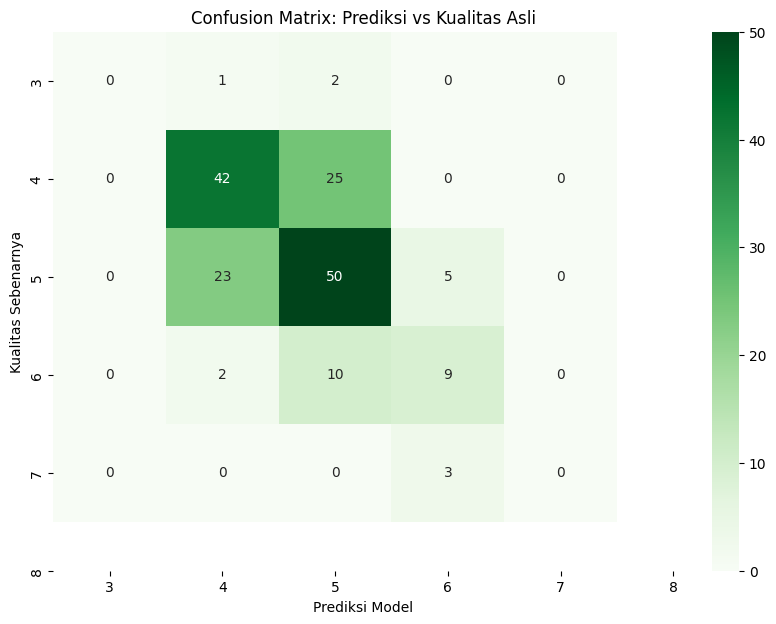

In [42]:
plt.figure(figsize=(10, 7))
cm = confusion_matrix(y_val, y_pred)
sb.heatmap(cm, annot=True, fmt='d', cmap='Greens',
           xticklabels=sorted(y.unique()),
           yticklabels=sorted(y.unique()))
plt.title('Confusion Matrix: Prediksi vs Kualitas Asli')
plt.xlabel('Prediksi Model')
plt.ylabel('Kualitas Sebenarnya')
plt.show()

In [43]:
# Menampilkan Laporan Klasifikasi Lengkap
print("\nLaporan Klasifikasi Detail:")
print(classification_report(y_val, y_pred))


Laporan Klasifikasi Detail:
              precision    recall  f1-score   support

           4       0.00      0.00      0.00         3
           5       0.62      0.63      0.62        67
           6       0.57      0.64      0.61        78
           7       0.53      0.43      0.47        21
           8       0.00      0.00      0.00         3

    accuracy                           0.59       172
   macro avg       0.34      0.34      0.34       172
weighted avg       0.57      0.59      0.58       172



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


PREDIKSI DATA UJI

In [44]:
# X_test_final adalah data dari data_testing.csv tanpa kolom 'Id'
hasil_prediksi = model_wine.predict(X_test_final)

In [51]:
# 2. Membuat DataFrame baru sesuai format Id dan Quality
df_hasilprediksi = pd.DataFrame({
    'Id': test_ids,
    'quality': hasil_prediksi
})

In [53]:
print("\nHasil Prediksi:")
print(df_hasilprediksi)


Hasil Prediksi:
       Id  quality
0     222        5
1    1514        5
2     417        5
3     754        5
4     516        5
..    ...      ...
281  1147        5
282   296        5
283   170        5
284  1439        5
285   946        7

[286 rows x 2 columns]


In [55]:
nama_file = 'hasilprediksi_106.csv'
df_hasilprediksi.to_csv(nama_file, index=False)